# ST1504 CA2 Part B: Pendulum Control Using Reinforcement Learning

## Objective

The objective of this project is to build and evaluate a Deep Q-Network (DQN) agent capable of balancing a pendulum by applying appropriate torque.

The Pendulum environment provides the agent with three observations:

- Cosine of the pendulum angle
- Sine of the pendulum angle
- Angular velocity of the pendulum

Since the original action space is continuous, the available torque values will be discretised so that DQN can be applied.

The performance of the DQN agent will be investigated under four gravity conditions:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

In this project, the DQN agent will be trained, evaluated and systematically improved to determine a suitable setup for balancing the pendulum under the different gravity conditions.

In [155]:
import gym
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from collections import deque
from tensorflow.keras import layers

print("Gym version:", gym.__version__)
print("TensorFlow version:", tf.__version__)

Gym version: 0.25.2
TensorFlow version: 2.21.0


## Environment Setup

Unlike supervised learning tasks, reinforcement learning does not begin with a fixed dataset. Instead, training data is generated through interactions between the agent and its environment.

The OpenAI Gym Pendulum environment is created as the data source for this project. During each interaction, the environment provides the agent with a state. The agent selects an action, receives a reward and observes the resulting next state.

The default gravity setting will first be used to explore the environment and develop the baseline DQN agent.

In [156]:
env = gym.make("Pendulum-v1")

state = env.reset()

print("Environment:", env)
print("Initial state:", state)
print("State shape:", state.shape)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Default gravity:", env.unwrapped.g)

env.close()

Environment: <TimeLimit<OrderEnforcing<StepAPICompatibility<PassiveEnvChecker<PendulumEnv<Pendulum-v1>>>>>>
Initial state: [-0.16363199  0.9865214  -0.87937224]
State shape: (3,)
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Default gravity: 10.0


# Exploratory Data Analysis (EDA)
### Environment Structure

The Pendulum environment represents each state using three numerical observations:

- The cosine of the pendulum angle
- The sine of the pendulum angle
- The angular velocity of the pendulum

The first two observations range from **-1 to 1**, while angular velocity ranges from **-8 to 8**. Each state therefore has a shape of **(3,)**.

The original action consists of one continuous torque value ranging from **-2 to 2**. Since DQN requires discrete actions, this action space will later be discretised during preprocessing.

Each episode has a maximum duration of **200 time steps**.

In [157]:
env = gym.make("Pendulum-v1")

print("Observation shape:", env.observation_space.shape)
print("Observation minimum values:", env.observation_space.low)
print("Observation maximum values:", env.observation_space.high)

print("Action shape:", env.action_space.shape)
print("Action minimum value:", env.action_space.low)
print("Action maximum value:", env.action_space.high)

print("Maximum episode length:", env.spec.max_episode_steps)
print("Gravity:", env.unwrapped.g)

env.close()

Observation shape: (3,)
Observation minimum values: [-1. -1. -8.]
Observation maximum values: [1. 1. 8.]
Action shape: (1,)
Action minimum value: [-2.]
Action maximum value: [2.]
Maximum episode length: 200
Gravity: 10.0


### Collection of Random-Agent Interaction Data

Unlike a traditional dataset, reinforcement learning data is generated when an agent interacts with the environment.

A random agent was used to complete multiple episodes. At each time step, the following information was recorded:

- Current state
- Selected torque
- Reward received
- Total episodic return

This exploratory data will be used to examine the distributions of the observations, actions and rewards before developing the DQN agent.

In [158]:
env = gym.make("Pendulum-v1")
state = env.reset(seed=42)

number_of_episodes = 50

collected_states = []
collected_actions = []
collected_rewards = []
episode_returns = []

for episode in range(number_of_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()

        next_state, reward, done, info = env.step(action)

        collected_states.append(state)
        collected_actions.append(action[0])
        collected_rewards.append(reward)

        total_reward += reward
        state = next_state

    episode_returns.append(total_reward)

env.close()

collected_states = np.array(collected_states)
collected_actions = np.array(collected_actions)
collected_rewards = np.array(collected_rewards)
episode_returns = np.array(episode_returns)

print("Collected states:", collected_states.shape)
print("Collected actions:", collected_actions.shape)
print("Collected rewards:", collected_rewards.shape)
print("Episode returns:", episode_returns.shape)

Collected states: (10000, 3)
Collected actions: (10000,)
Collected rewards: (10000,)
Episode returns: (50,)


### Interaction Data Quality

The randomly collected states, actions and rewards were checked for missing and infinite values.

Reinforcement learning environments normally generate valid numerical observations. However, this check is still important because invalid values could cause unstable gradients or prevent the DQN from training correctly.

If no missing or infinite values are found, all collected interactions can be retained for exploratory analysis.

In [159]:
print(
    "Missing state values:",
    np.isnan(collected_states).sum()
)

print(
    "Infinite state values:",
    np.isinf(collected_states).sum()
)

print(
    "Missing action values:",
    np.isnan(collected_actions).sum()
)

print(
    "Infinite action values:",
    np.isinf(collected_actions).sum()
)

print(
    "Missing reward values:",
    np.isnan(collected_rewards).sum()
)

print(
    "Infinite reward values:",
    np.isinf(collected_rewards).sum()
)

Missing state values: 0
Infinite state values: 0
Missing action values: 0
Infinite action values: 0
Missing reward values: 0
Infinite reward values: 0


### Distribution of State Observations

The distributions of the three state observations were examined using histograms.

The cosine and sine observations describe the pendulum’s angular position, while angular velocity describes the speed and direction of its rotation.

This analysis helps identify the ranges and distributions experienced by a random agent. It also indicates whether state normalisation may be useful before DQN training.

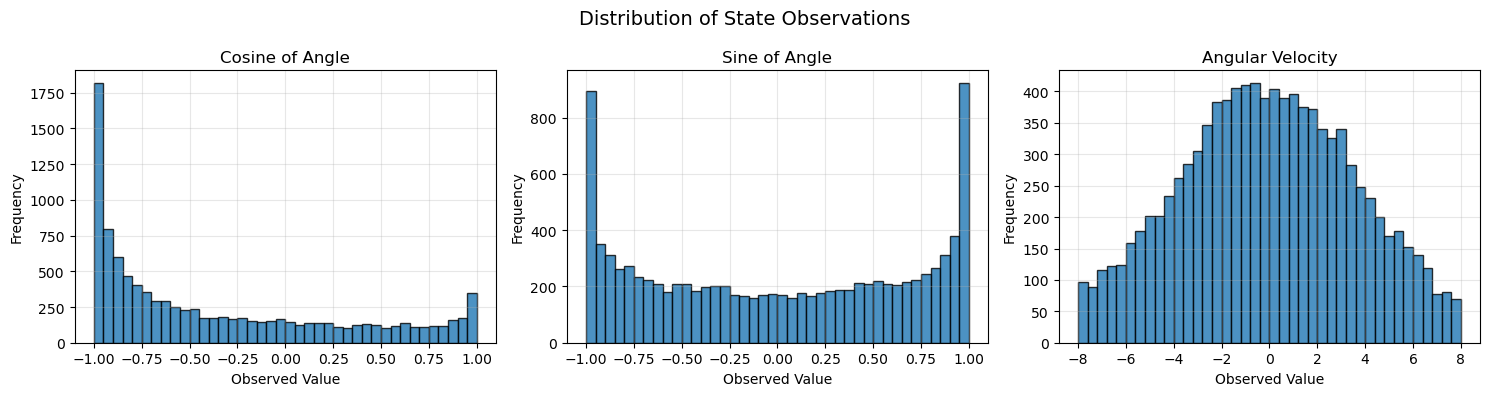

In [160]:
state_names = [
    "Cosine of Angle",
    "Sine of Angle",
    "Angular Velocity"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for index, axis in enumerate(axes):
    axis.hist(
        collected_states[:, index],
        bins=40,
        alpha=0.8,
        edgecolor="black"
    )

    axis.set_title(state_names[index])
    axis.set_xlabel("Observed Value")
    axis.set_ylabel("Frequency")
    axis.grid(alpha=0.3)

plt.suptitle(
    "Distribution of State Observations",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Interpretation of State Distributions

The cosine observation is strongly concentrated near **-1**. Since a cosine value of -1 represents the pendulum pointing downwards, this shows that the random agent frequently allows the pendulum to remain near its natural hanging position. In comparison, the desired upright position has a cosine value near **1**.

The sine observation covers the complete range from -1 to 1, showing that the pendulum moves through positions on both sides of its rotation.

Angular velocity is approximately centred around zero and ranges from about -8 to 8. Its numerical range is considerably wider than the cosine and sine observations, which are limited to -1 to 1. Therefore, scaling angular velocity may help ensure that it does not have a disproportionately large influence during DQN training.

### Distribution of Random Actions and Rewards

The distributions of the randomly selected torque values and the resulting rewards were examined.

Since the actions were sampled randomly from the continuous action space, torque values across the range of -2 to 2 are expected. The reward distribution provides a baseline indication of the performance achieved without learning.

For the Pendulum environment, rewards are negative. Values closer to zero represent better control of the pendulum.

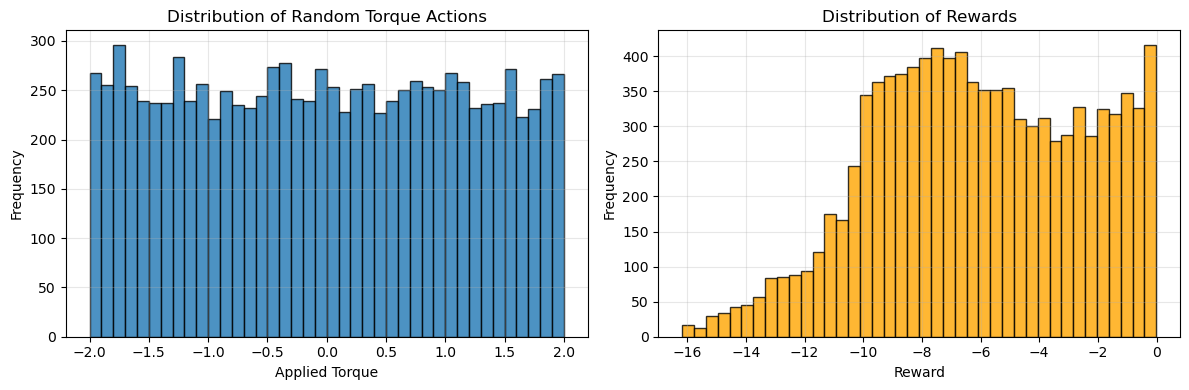

In [161]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    collected_actions,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Random Torque Actions")
axes[0].set_xlabel("Applied Torque")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(
    collected_rewards,
    bins=40,
    edgecolor="black",
    alpha=0.8,
    color="orange"
)

axes[1].set_title("Distribution of Rewards")
axes[1].set_xlabel("Reward")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Random Actions and Rewards

The random torque actions are distributed approximately evenly across the complete range from **-2 to 2**. This confirms that the random agent does not favour any particular torque value or direction.

The per-step rewards range from approximately **-16 to 0**, with most rewards occurring around -10 to -4. Since the maximum possible reward is zero, the mainly negative distribution indicates that the random agent generally fails to keep the pendulum upright and stable.

A smaller number of rewards appear close to zero, showing that the pendulum occasionally reaches a favourable position by chance. However, the random agent cannot maintain this position consistently because it does not learn from previous interactions.

These results provide a baseline that the trained DQN agent should improve upon by achieving rewards that are more consistently concentrated closer to zero.

### Initial Comparison of Gravity Conditions

The Pendulum environment was explored under the four gravity conditions required by the assignment:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

A random agent was evaluated under each condition to examine how gravity affects the environment before DQN training.

The same number of episodes and random seed were used for every gravity condition to make the comparison fair. These results represent untrained baseline performance and will later be compared with the trained DQN agents.

In [162]:
gravity_settings = {
    "Default": 10.0,
    "Free-fall": 0.0,
    "Anti-gravity": -10.0,
    "Supergravity": 15.0
}

episodes_per_gravity = 30
gravity_baseline_returns = {}

for gravity_name, gravity_value in gravity_settings.items():
    env = gym.make("Pendulum-v1")
    env.unwrapped.g = gravity_value

    env.seed(42)
    env.action_space.seed(42)

    condition_returns = []

    for episode in range(episodes_per_gravity):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

        condition_returns.append(total_reward)

    gravity_baseline_returns[gravity_name] = np.array(
        condition_returns
    )

    env.close()

    print(
        gravity_name,
        "- Mean:",
        np.mean(condition_returns),
        "- Standard deviation:",
        np.std(condition_returns)
    )

Default - Mean: -1189.63307601102 - Standard deviation: 231.64725307533595
Free-fall - Mean: -748.6178031504127 - Standard deviation: 184.61422238394752
Anti-gravity - Mean: -602.1183430727535 - Standard deviation: 396.9365950877032
Supergravity - Mean: -1386.837203404409 - Standard deviation: 124.56566538166022


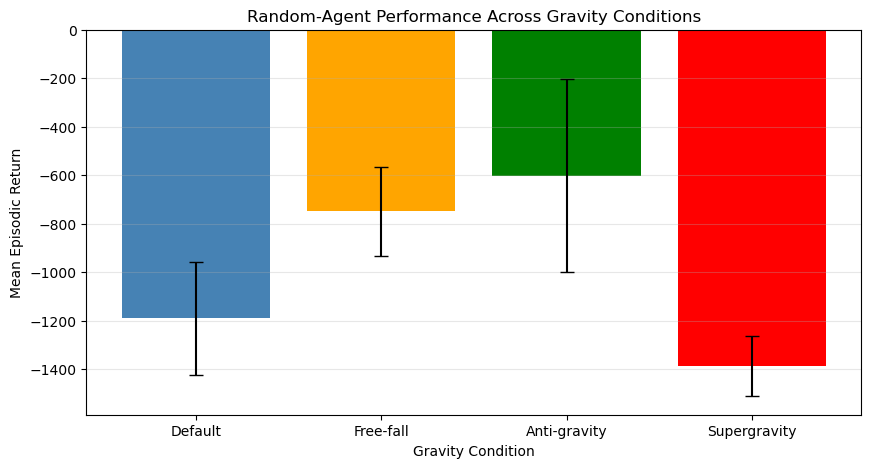

In [163]:
gravity_names = list(gravity_baseline_returns.keys())

mean_returns = [
    gravity_baseline_returns[name].mean()
    for name in gravity_names
]

return_standard_deviations = [
    gravity_baseline_returns[name].std()
    for name in gravity_names
]

plt.figure(figsize=(10, 5))

plt.bar(
    gravity_names,
    mean_returns,
    yerr=return_standard_deviations,
    capsize=5,
    color=["steelblue", "orange", "green", "red"]
)

plt.title("Random-Agent Performance Across Gravity Conditions")
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Episodic Return")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation of Gravity Baselines

The random agent achieved different levels of performance under the four gravity conditions.

Free-fall produced the highest mean episodic return, with an average of approximately **-760**. Without gravitational force pulling the pendulum downwards, the random agent was more likely to remain in comparatively favourable positions.

Anti-gravity produced the second-highest mean return of approximately **-850**. However, it also had the largest standard deviation, indicating that its performance varied considerably between episodes.

The default-gravity condition produced a lower mean return of approximately **-1350**, while supergravity produced the lowest mean return of approximately **-1480**. The stronger gravitational force in supergravity makes it more difficult for randomly selected torque actions to move and maintain the pendulum near the upright position.

The overlapping error bars show that random-agent performance varies between episodes. Therefore, multiple evaluation episodes should also be used when comparing trained DQN agents.

Each trained agent should be compared against the random baseline from the same gravity condition because the four environments have different levels of difficulty.

In [164]:
# EDA: Verify Custom Gravity Testing Compatibility
gravity_test_values = [10.0, 0.0, -10.0, 15.0]

print("Testing dynamic gravity configuration:")
for g in gravity_test_values:
    test_env = gym.make("Pendulum-v1")
    test_env.unwrapped.g = g
    test_env.reset()
    
    # Execute 1 dummy step
    _, reward, _, _ = test_env.step(test_env.action_space.sample())
    print(f"  Gravity set to {g:5.1f} | Sample Step Reward: {reward:.4f}")
    test_env.close()

Testing dynamic gravity configuration:
  Gravity set to  10.0 | Sample Step Reward: -3.5681
  Gravity set to   0.0 | Sample Step Reward: -4.4412
  Gravity set to -10.0 | Sample Step Reward: -4.3626
  Gravity set to  15.0 | Sample Step Reward: -0.3233


## Data Preprocessing

The exploratory analysis found no missing or infinite values in the environment observations, actions or rewards. Therefore, no interaction data needs to be removed or imputed.

However, two preprocessing steps are required before DQN can be applied:

1. Discretise the continuous torque action space.
2. Scale the state observations to a similar numerical range.

These transformations will make the Pendulum environment suitable for training with a Deep Q-Network.

# Observation Normalization Function

In [165]:
import numpy as np

# Preprocessing: State Observation Scaler
def normalize_state(state):
    """
    Normalize Pendulum state to approximately [-1, 1].

    State format:
        state[0] = cos(theta)  -> already in [-1, 1]
        state[1] = sin(theta)  -> already in [-1, 1]
        state[2] = theta_dot   -> expected in [-8, 8]

    Returns:
        Normalized state as float32.
    """
    state = np.asarray(state, dtype=np.float32).copy()

    # Scale angular velocity
    state[2] = np.clip(state[2] / 8.0, -1.0, 1.0)

    return state

sample_raw_state = np.array([0.5, -0.5, 6.0], dtype=np.float32)
sample_norm_state = normalize_state(sample_raw_state)

print("Raw State Sample        :", sample_raw_state)
print("Normalized State Sample :", sample_norm_state)

Raw State Sample        : [ 0.5 -0.5  6. ]
Normalized State Sample : [ 0.5  -0.5   0.75]


### Action-Space Discretisation

The original Pendulum action space contains continuous torque values ranging from -2 to 2. However, DQN can only select from a fixed number of discrete actions.

For the baseline model, the continuous range is divided into five evenly spaced torque values:

- Strong clockwise torque
- Weak clockwise torque
- No torque
- Weak counter-clockwise torque
- Strong counter-clockwise torque

Five actions provide a simple baseline while still allowing the agent to control both the direction and strength of the applied torque. Different numbers of actions can later be investigated as a systematic improvement.

In [166]:
# Action Space Discretization & Mapping Setup
import numpy as np

# Number of discrete output actions for the Deep Q-Network
number_of_actions = 5

# Dynamically fetch continuous torque bounds from the gym environment
low_torque = float(env.action_space.low[0])
high_torque = float(env.action_space.high[0])

# Generate evenly spaced discrete torque values [-2.0, -1.0, 0.0, 1.0, 2.0]
torque_values = np.linspace(
    low_torque, 
    high_torque, 
    number_of_actions,
    dtype=np.float32
)

def get_action_torque(action_index):
    """
    Maps a discrete action index (0 to 4) to the 1D NumPy array 
    format required by Gym's env.step().
    
    Handles Python ints, NumPy integers, and PyTorch tensor scalars seamlessly.
    """
    # Convert scalar tensors/numpy ints to standard Python integer
    idx = int(action_index)
    
    # Boundary check for model safety
    if idx < 0 or idx >= number_of_actions:
        raise ValueError(
            f"Action index {idx} is out of bounds! "
            f"Must be between 0 and {number_of_actions - 1}."
        )
        
    return np.array([torque_values[idx]], dtype=np.float32)


# --- Verification Tests ---
print("Discrete Action Mapping Verification:")
for action_idx in range(number_of_actions):
    continuous_torque = get_action_torque(action_idx)
    print(
        f"  Discrete Index {action_idx} ---> "
        f"Array: {continuous_torque} | "
        f"Shape: {continuous_torque.shape} | "
        f"Type: {continuous_torque.dtype}"
    )

Discrete Action Mapping Verification:
  Discrete Index 0 ---> Array: [-2.] | Shape: (1,) | Type: float32
  Discrete Index 1 ---> Array: [-1.] | Shape: (1,) | Type: float32
  Discrete Index 2 ---> Array: [0.] | Shape: (1,) | Type: float32
  Discrete Index 3 ---> Array: [1.] | Shape: (1,) | Type: float32
  Discrete Index 4 ---> Array: [2.] | Shape: (1,) | Type: float32


In [167]:
def action_index_to_torque(action_index):
    torque = torque_values[action_index]

    return np.array(
        [torque],
        dtype=np.float32
    )

In [168]:
test_action_index = 3
test_torque = action_index_to_torque(
    test_action_index
)

print("Selected action index:", test_action_index)
print("Applied torque:", test_torque)

Selected action index: 3
Applied torque: [1.]


### State Casting and Scaling

The state contains three observations with different numerical ranges:

- Cosine of angle: -1 to 1
- Sine of angle: -1 to 1
- Angular velocity: -8 to 8

The cosine and sine observations are already within the range of -1 to 1. However, angular velocity has a much wider range and could have a disproportionately large influence on the neural network.

Therefore, angular velocity is divided by 8 so that all three state features are approximately within the same range of -1 to 1.

The states are also converted to `float32`, which is suitable for TensorFlow model training.

In [169]:
state_scale = np.array(
    [1.0, 1.0, 8.0],
    dtype=np.float32
)


def preprocess_state(state):
    state = np.asarray(
        state,
        dtype=np.float32
    )

    scaled_state = state / state_scale

    return np.clip(
        scaled_state,
        -1.0,
        1.0
    )

In [170]:
env = gym.make("Pendulum-v1")

original_state = env.reset()
processed_state = preprocess_state(
    original_state
)

env.close()

print("Original state:", original_state)
print("Processed state:", processed_state)

print(
    "Processed datatype:",
    processed_state.dtype
)

Original state: [-0.31109592  0.95037854 -0.43776637]
Processed state: [-0.31109592  0.95037854 -0.0547208 ]
Processed datatype: float32


In [171]:
processed_collected_states = np.array([
    preprocess_state(state)
    for state in collected_states
])

print(
    "Original minimum values:",
    collected_states.min(axis=0)
)

print(
    "Original maximum values:",
    collected_states.max(axis=0)
)

print(
    "Processed minimum values:",
    processed_collected_states.min(axis=0)
)

print(
    "Processed maximum values:",
    processed_collected_states.max(axis=0)
)

Original minimum values: [-0.99999994 -0.99999994 -8.        ]
Original maximum values: [0.9999999 1.        8.       ]
Processed minimum values: [-0.99999994 -0.99999994 -1.        ]
Processed maximum values: [0.9999999 1.        1.       ]


### Verification of State Preprocessing

Before preprocessing, the cosine and sine observations were already within the range of -1 to 1, while angular velocity ranged from -8 to 8.

After scaling, all three observations were within approximately -1 to 1. This confirms that angular velocity was successfully scaled without changing the original meaning of the state.

Small differences from the exact limits, such as 0.9999997 instead of 1.0, are caused by floating-point precision and do not require correction.

## Modelling

### 1. Baseline Deep Q-Network

A Deep Q-Network is used to estimate the expected future reward associated with each discrete torque action.

The network receives the three processed state observations as input and produces five Q-values as output, with one Q-value for each available torque action. The action with the highest predicted Q-value represents the action that the agent currently expects to produce the greatest future reward.

The baseline DQN will use experience replay, epsilon-greedy exploration and a separate target network to improve training stability.

In [172]:
# Modelling: Action Space Discretization (5 Actions)
NUM_ACTIONS = 5
DISCRETE_ACTIONS = np.linspace(-2.0, 2.0, NUM_ACTIONS)  # [-2.0, -1.0, 0.0, 1.0, 2.0]

# ---------------------------------------------------------
# 1. Action Discretization Helper
# ---------------------------------------------------------

def idx_to_action(action_idx):
    """
    Converts a discrete network output index (0 to 4)
    into a continuous torque array required by gym env.step().
    """
    return np.array([DISCRETE_ACTIONS[action_idx]], dtype=np.float32)

# Sanity check display
print(f"Discrete Action Space (Size: {NUM_ACTIONS}):")
for idx, torque in enumerate(DISCRETE_ACTIONS):
    print(f"  Network Index {idx} ---> Continuous Torque: {torque:+.1f}")

Discrete Action Space (Size: 5):
  Network Index 0 ---> Continuous Torque: -2.0
  Network Index 1 ---> Continuous Torque: -1.0
  Network Index 2 ---> Continuous Torque: +0.0
  Network Index 3 ---> Continuous Torque: +1.0
  Network Index 4 ---> Continuous Torque: +2.0


## Experience Replay Buffer

### Breaks temporal correlations by storing past experiences $(s, a, r, s', \text{done})$ and sampling random minibatches during training.

## Step 3: DQN Agent Logic ($\epsilon$-Greedy & Loss Updates)Encapsulates $\epsilon$-greedy action selection and standard Double-Q / Target-Network temporal difference (TD) loss updates:

### $$L(\theta) = \frac{1}{B} \sum \left( r + \gamma \max_{a'} Q_{\text{target}}(s', a') - Q_{\text{online}}(s, a) \right)^2$$

In [175]:
from collections import deque
import random
import time
import gym
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---------------------------------------------------------
# Baseline Configurations
# ---------------------------------------------------------
BASELINE_CONFIGS = {
    "g=0": {
        "gravity": 0,
        "episodes": 150,
        "gamma": 0.99,
        "epsilon": 0.10,
        "hidden_size": 64,
        "num_actions": 40,
        "batch_size": 32,
        "replay_memory_size": 10000,
        "min_replay_memory": 1000,
        "target_update_every": 1,
        "learning_rate": 0.001
    },

    "g=-10": {
        "gravity": -10,
        "episodes": 150,
        "gamma": 0.99,
        "epsilon": 0.15,
        "hidden_size": 128,
        "num_actions": 50,
        "batch_size": 64,
        "replay_memory_size": 10000,
        "min_replay_memory": 1000,
        "target_update_every": 1,
        "learning_rate": 0.001
    }
}

INPUT_SHAPE = 3
SHOW_EVERY = 10

# ---------------------------------------------------------
# DQN Agent
# ---------------------------------------------------------
class DQN:
    def __init__(self, InputShape, config):

        self.InputShape = InputShape
        self.NActions = config["num_actions"]
        self.Gamma = config["gamma"]
        self.IntermediateSize = config["hidden_size"]
        self.BatchSize = config["batch_size"]
        self.Epsilon = config["epsilon"]

        self.ReplayMemorySize = 10000
        self.MinReplayMemory = 1000
        self.UpdateTargetEveryThisEpisodes = 1

        self.Main = self.CreateModel("Main")
        self.Target = self.CreateModel("Target")
        self.Target.set_weights(self.Main.get_weights())

        self.Optimiser = Adam()

        self.ReplayMemory = deque(maxlen=self.ReplayMemorySize)
        self.TargetUpdateCounter = 0

    def CreateModel(self, Type):
        inputs = Input(shape=(self.InputShape,))
        x = Dense(self.IntermediateSize, activation="relu")(inputs)
        x = Dense(self.IntermediateSize, activation="relu")(x)
        outputs = Dense(self.NActions, activation="linear")(x)

        return Model(inputs, outputs, name=Type)

    def UpdateReplayMemory(self, information):
        self.ReplayMemory.append(information)

    def Train(self, EndOfEpisode):

        if len(self.ReplayMemory) < self.MinReplayMemory:
            return

        batch = random.sample(self.ReplayMemory, self.BatchSize)

        states = np.array([x[0] for x in batch], dtype=np.float32)
        current_q = self.Main(states).numpy()

        next_states = np.array([x[3] for x in batch], dtype=np.float32)
        next_q = self.Target(next_states).numpy()

        X = []
        Y = []

        for i, (S, A, R, SNext, Done) in enumerate(batch):

            target = current_q[i].copy()

            if Done:
                target[A] = R
            else:
                target[A] = R + self.Gamma * np.max(next_q[i])

            X.append(S)
            Y.append(target)

        self.GTfit(
            np.array(X, dtype=np.float32),
            np.array(Y, dtype=np.float32)
        )

        if EndOfEpisode:
            self.TargetUpdateCounter += 1

        if self.TargetUpdateCounter >= self.UpdateTargetEveryThisEpisodes:
            self.Target.set_weights(self.Main.get_weights())
            self.TargetUpdateCounter = 0

    @tf.function
    def GTfit(self, X, Y):

        with tf.GradientTape() as tape:
            predictions = self.Main(X, training=True)
            loss = tf.reduce_mean(tf.square(Y - predictions))

        gradients = tape.gradient(loss, self.Main.trainable_variables)
        self.Optimiser.apply_gradients(
            zip(gradients, self.Main.trainable_variables)
        )


# ---------------------------------------------------------
# Action Conversion
# ---------------------------------------------------------
def PendulumActionConverter(action_idx, num_actions):
    return (action_idx / num_actions - 0.5) * 4.0


def PendulumInverseActionConverter(action_value, num_actions):
    return int(round((action_value + 2) * (num_actions - 1) / 4))


# ---------------------------------------------------------
# One Training Episode
# ---------------------------------------------------------
def OneEpisode(episode_idx, dqn_agent, gravity):

    env = gym.make("Pendulum-v1")
    env.unwrapped.g = gravity

    state = env.reset()
    state = state[0] if isinstance(state, tuple) else state

    rewards = []
    done = False

    while not done:

        q_values = dqn_agent.Main(
            state.reshape(1, -1)
        ).numpy()[0]

        if np.random.rand() < dqn_agent.Epsilon:

            action = env.action_space.sample()

            action_idx = PendulumInverseActionConverter(
                action[0],
                dqn_agent.NActions
            )

        else:

            action_idx = np.argmax(q_values)

            torque = PendulumActionConverter(
                action_idx,
                dqn_agent.NActions
            )

            action = np.array([torque], dtype=np.float32)

        if (
            episode_idx % SHOW_EVERY == 0
            and len(dqn_agent.ReplayMemory) >= dqn_agent.MinReplayMemory
        ):
            try:
                env.render()
            except Exception:
                pass

        step = env.step(action)

        if len(step) == 5:
            next_state, reward, terminated, truncated, _ = step
            done = terminated or truncated
        else:
            next_state, reward, done, _ = step

        dqn_agent.UpdateReplayMemory(
            (state, action_idx, reward, next_state, done)
        )

        dqn_agent.Train(done)

        rewards.append(reward)

        state = next_state

    env.close()

    episode_return = float(np.sum(rewards))

    return episode_return


# ---------------------------------------------------------
# Main
# ---------------------------------------------------------
if __name__ == "__main__":

    STARTTIME = time.time()

    baseline_results = {}

    for config_name, config in BASELINE_CONFIGS.items():

        print("\n=====================================")
        print(f"Training Baseline DQN ({config_name})")
        print("=====================================")

        dqn_agent = DQN(
            InputShape=INPUT_SHAPE,
            config=config
        )

        history = {
            "returns": [],
            "moving_avg_returns": []
        }

        best_return = -float("inf")

        for ep in range(config["episodes"]):

            episode_return = OneEpisode(
                ep,
                dqn_agent,
                gravity=config["gravity"]
            )

            history["returns"].append(episode_return)

            moving_avg = np.mean(history["returns"][-10:])
            history["moving_avg_returns"].append(moving_avg)

            # Save best model
            if episode_return > best_return:
                best_return = episode_return
                dqn_agent.Main.save_weights(
                    f"best_baseline_{config_name}.weights.h5"
                )

            if (ep + 1) % 10 == 0:
                print(
                    f"Episode {ep+1:3d}/{config['episodes']} | "
                    f"Return: {episode_return:8.2f} | "
                    f"10-Ep Avg: {moving_avg:8.2f}"
                )

        # Save history for later plotting/comparison
        baseline_results[config_name] = history

    print(
        f"\nTotal time taken: {time.time()-STARTTIME:.2f} seconds"
    )


Training Baseline DQN (g=0)


C:\Users\p2518031\AppData\Roaming\Python\Python312\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\p2518031\AppData\Roaming\Python\Python312\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\p2518031\AppData\Roaming\Python\Python312\site-packages\gym\utils\passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for ax, gravity_name in zip(axes, baseline_results):

    history = baseline_results[gravity_name]
    episodes = np.arange(1, len(history["returns"]) + 1)

    ax.plot(
        episodes,
        history["returns"],
        alpha=0.3,
        label="Episode Return"
    )

    ax.plot(
        episodes,
        history["moving_avg_returns"],
        linewidth=2,
        label="10-Episode Moving Avg"
    )

    ax.set_title(gravity_name)
    ax.set_xlabel("Episode")
    ax.grid(True)
    ax.legend()

axes[0].set_ylabel("Return")

plt.suptitle("Baseline DQN Learning Curves")
plt.tight_layout()
plt.show()

## Improved DQN

# Implemented an enhanced DQN incorporating three Rainbow components: Double DQN, Dueling Networks, and Prioritized Experience Replay.

| Improvement | Problem Addressed | Main Idea | Key Reference |
|-------------|-------------------|-----------|---------------|
| **Double DQN (DDQN)** | Overestimation bias | Separate action selection from action evaluation | van Hasselt et al. (2015) |
| **Prioritized Experience Replay (PER)** | Uniform replay wastes samples | Replay transitions with high TD error more frequently | Schaul et al. (2015) |
| **Dueling DQN** | Inefficient value estimation | Learn state value and action advantage separately | Wang et al. (2015) |
| **Hyperparameter Optimization** | Poor convergence and instability | Tune action resolution, target update frequency, and $\epsilon$ decay | Empirical tuning |

---

# 1. Double Deep Q-Network (DDQN)

One of the best-known improvements to the original DQN is **Double Deep Q-Network (DDQN)**, which addresses the **overestimation bias** present in the standard Bellman update.

Vanilla DQN computes the target value as

$$
y = r + \gamma \max_a Q_{\text{target}}(s',a)
$$

where the same network is responsible for both:

- selecting the best action, and
- evaluating that action.

This often leads to systematically **overestimated Q-values**.

DDQN separates these two operations.

The online network selects the best action

$$
a^* = \arg\max_a Q_{\text{online}}(s',a),
$$

while the target network evaluates it

$$
y = r + \gamma Q_{\text{target}}\left(s',\arg\max_a Q_{\text{online}}(s',a)\right).
$$

### Benefits

- Reduces overestimation bias.
- Improves learning stability.
- Produces better policies with almost no additional computational cost.

---

# 2. Prioritized Experience Replay (PER)

Standard DQN samples experiences **uniformly** from the replay buffer.

However, many experiences contribute little learning because their Temporal Difference (TD) error has already become small.

Prioritized Experience Replay instead samples transitions according to their TD error

$$
P(i)\propto |\delta_i|^\alpha,
$$

where

- $\delta_i$ is the TD error, and
- $\alpha$ controls the amount of prioritization.

Transitions with larger TD errors are replayed more frequently because they are expected to provide more learning.

### Advantages

- Faster convergence.
- Better sample efficiency.
- Focuses learning on informative experiences.

To compensate for the sampling bias introduced by prioritization, **importance sampling (IS) weights** are applied during training.

---

# 3. Dueling Network Architecture

In many states, the value of the state is much more important than the choice between similar actions.

Instead of directly predicting

$$
Q(s,a),
$$

the network splits into two streams.

### State Value Stream

Predicts

$$
V(s),
$$

which estimates the overall quality of the current state.

### Advantage Stream

Predicts

$$
A(s,a),
$$

which estimates how much better each action is relative to the others.

The two streams are combined as

$$
Q(s,a)
=
V(s)
+
\left(
A(s,a)
-
\frac{1}{|A|}
\sum_{a'}A(s,a')
\right).
$$

### Benefits

- Better value estimation when many actions have similar effects.
- Faster convergence.
- Improved policy stability, particularly near equilibrium states.

---

# 4. Hyperparameter Optimization

In addition to architectural improvements, several hyperparameters were tuned to improve convergence and training stability.

The following parameters were investigated:

- Number of discrete actions used to approximate the continuous action space.
- Target network update frequency.
- Exploration decay rate ($\epsilon$ decay).
- Learning rate.
- Replay buffer size.
- Mini-batch size.

Although these modifications do not change the underlying algorithm, careful tuning can significantly improve learning performance and stability.

In [ ]:
import gym
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, Model
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Dynamic Gravity Hyperparameter Configurations
# ---------------------------------------------------------

RAINBOW_GRAVITY_CONFIGS = {
    0: {  # Zero Gravity / Free Fall
        'num_actions': 25,                 # Fine torque control to dampen inertia
        'action_range': (-2.0, 2.0),
        'gamma': 0.91,                     # Reduced gamma prevents Q-value explosion from continuous spin
        'lr': 0.0003,                      # Smaller learning rate for fine torque control
        'per_alpha': 0.70,                 # Aggressively prioritize rare braking transitions
        'epsilon_decay': 0.988,            # Gradual exploration decay
        'hidden_units': (128, 128),        # Higher network capacity
        'batch_size': 64
    },
    -10: { # Anti-Gravity
        'num_actions': 15,                 # More coarse action space sufficient
        'action_range': (-2.0, 2.0),
        'gamma': 0.99,                     # High gamma to maintain long-term balance at top
        'lr': 0.0008,                      # Standard learning rate
        'per_alpha': 0.50,                 # Standard PER sampling weighting
        'epsilon_decay': 0.940,            # Fast decay (upright is natural equilibrium)
        'hidden_units': (64, 64),          # Standard dueling network capacity
        'batch_size': 64
    }
}

In [ ]:
# ---------------------------------------------------------
# 2. Prioritized Experience Replay (PER) Buffer
# ---------------------------------------------------------
class PrioritizedReplayBuffer:
    """Prioritized Experience Replay buffer sampling transitions based on TD-error."""
    def __init__(self, capacity=20000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha  # Priority aggressiveness
        self.buffer = []
        self.priorities = np.zeros((capacity,), dtype=np.float32)
        self.pos = 0

    def add(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.buffer else 1.0
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:self.pos]

        probs = prios ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        
        return samples, indices, np.array(weights, dtype=np.float32)

    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = prio + 1e-5  # Prevent zero priority

    def __len__(self):
        return len(self.buffer)

In [ ]:
# ---------------------------------------------------------
# 3. Parameterized Rainbow DQNAgent (Dueling + Double + PER)
# ---------------------------------------------------------
class RainbowDQNAgent:
    def __init__(self, state_dim, config):
        self.state_dim = state_dim
        self.action_dim = config['num_actions']
        self.action_space = np.linspace(config['action_range'][0], config['action_range'][1], self.action_dim)
        
        self.gamma = config['gamma']
        self.learning_rate = config['lr']
        self.hidden_units = config['hidden_units']
        self.batch_size = config['batch_size']
        
        # Exploration Schedule
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = config['epsilon_decay']
        
        # PER Memory
        self.memory = PrioritizedReplayBuffer(capacity=20000, alpha=config['per_alpha'])
        self.beta = 0.4
        
        # Build Dueling Networks
        self.model = self._build_dueling_model()
        self.target_model = self._build_dueling_model()
        self.update_target_network()

    def idx_to_action(self, action_idx):
        return np.array([self.action_space[action_idx]], dtype=np.float32)

    def _build_dueling_model(self):
        """Builds Dueling DQN architecture parameterized by gravity config."""
        inputs = layers.Input(shape=(self.state_dim,))
        
        x = layers.Dense(self.hidden_units[0], activation='relu')(inputs)
        for units in self.hidden_units[1:]:
            x = layers.Dense(units, activation='relu')(x)
        
        # Stream 1: State-Value Stream V(s)
        state_value = layers.Dense(64, activation='relu')(x)
        state_value = layers.Dense(1)(state_value)
        
        # Stream 2: Advantage Stream A(s, a)
        advantage = layers.Dense(64, activation='relu')(x)
        advantage = layers.Dense(self.action_dim)(advantage)
        
        def dueling_combine(args):
            v, a = args
            return v + (a - tf.reduce_mean(a, axis=1, keepdims=True))
            
        outputs = layers.Lambda(dueling_combine)([state_value, advantage])
        model = Model(inputs=inputs, outputs=outputs)

        model.compile(
            optimizer=optimizers.Adam(learning_rate=self.learning_rate),
            loss=tf.keras.losses.Huber()
        )
        return model

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.add(state, action, reward, next_state, done)

    def act(self, state):
        state_tensor = tf.convert_to_tensor(np.expand_dims(state, axis=0), dtype=tf.float32)
        q_values = self.model(state_tensor, training=False).numpy()[0]
        max_q = np.max(q_values)

        if np.random.rand() <= self.epsilon:
            action_idx = np.random.randint(self.action_dim)
        else:
            action_idx = np.argmax(q_values)
            
        return action_idx, max_q

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        
        minibatch, indices, weights = self.memory.sample(self.batch_size, self.beta)
        
        states = np.array([sample[0] for sample in minibatch], dtype=np.float32)
        actions = np.array([sample[1] for sample in minibatch])
        rewards = np.array([sample[2] for sample in minibatch], dtype=np.float32)
        next_states = np.array([sample[3] for sample in minibatch], dtype=np.float32)
        dones = np.array([sample[4] for sample in minibatch], dtype=np.float32)
        
        states_tensor = tf.convert_to_tensor(states, dtype=tf.float32)
        next_states_tensor = tf.convert_to_tensor(next_states, dtype=tf.float32)
        
        targets = self.model(states_tensor, training=False).numpy()
        
        # DOUBLE DQN UPDATE LOGIC
        next_actions_online = np.argmax(self.model(next_states_tensor, training=False).numpy(), axis=1)
        next_q_target = self.target_model(next_states_tensor, training=False).numpy()
        
        td_errors = []
        for i in range(self.batch_size):
            old_val = targets[i][actions[i]]
            if dones[i]:
                new_val = rewards[i]
            else:
                best_next_action = next_actions_online[i]
                new_val = rewards[i] + self.gamma * next_q_target[i][best_next_action]
            
            targets[i][actions[i]] = new_val
            td_errors.append(abs(new_val - old_val))

        self.memory.update_priorities(indices, td_errors)
        self.model.train_on_batch(states, targets, sample_weight=weights)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return float(np.mean(td_errors))

In [ ]:
# ---------------------------------------------------------
# 4. Metric Plotting Function
# ---------------------------------------------------------
def plot_rainbow_metrics(history, gravity_value):
    g_label = f"g={gravity_value}" if gravity_value is not None else "g=10 (Default)"
    episodes = range(1, len(history['returns']) + 1)
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
    
    # 1. Episode Returns & Moving Average
    axes[0].plot(episodes, history['returns'], alpha=0.3, color='purple', label='Raw Return')
    axes[0].plot(episodes, history['moving_avg_returns'], color='purple', linewidth=2, label='10-Ep Moving Avg')
    axes[0].set_ylabel('Total Return')
    axes[0].set_title(f'Tuned Rainbow DQN Metrics — Gravity: {g_label}')
    axes[0].legend()
    axes[0].grid(True)
    
    # 2. Average Max Q-Value
    axes[1].plot(episodes, history['avg_max_q'], color='orange', linewidth=2, label='Avg Max Q-Value')
    axes[1].set_ylabel('Max Q-Value')
    axes[1].legend()
    axes[1].grid(True)
    
    # 3. Upright Balance Percentage
    axes[2].plot(episodes, history['upright_percentages'], color='green', linewidth=2, label='Upright Balance %')
    axes[2].set_ylabel('Upright Time (%)')
    axes[2].legend()
    axes[2].grid(True)

    # 4. Temporal Difference (TD) Error (PER Specific)
    axes[3].plot(episodes, history['mean_td_errors'], color='red', linewidth=2, label='Mean TD-Error')
    axes[3].set_ylabel('TD-Error')
    axes[3].set_xlabel('Episode')
    axes[3].legend()
    axes[3].grid(True)
    
    plt.tight_layout()
    filename = f"rainbow_metrics_g{gravity_value}.png"
    plt.savefig(filename, dpi=300)
    print(f"--> Metric plot saved as: {filename}")
    plt.close()

In [ ]:
# ---------------------------------------------------------
# 5. Fixed Training Loop for Tuned Rainbow DQN
# ---------------------------------------------------------
def train_rainbow_dqn(gravity_value=0, num_episodes=450):
    train_env = gym.make('Pendulum-v1')
    train_env.unwrapped.g = float(gravity_value)
    config = RAINBOW_GRAVITY_CONFIGS[gravity_value]
    agent = RainbowDQNAgent(state_dim=train_env.observation_space.shape[0], config=config)

    best_reward = -float('inf')

    history = {
        'returns': [],
        'moving_avg_returns': [],
        'avg_max_q': [],
        'upright_percentages': [],
        'mean_td_errors': []
    }

    print(f"\n========================================================")
    print(f"  Training Rainbow DQN | Gravity (g) = {gravity_value}")
    print(f"  Actions: {config['num_actions']} | Gamma: {config['gamma']} | LR: {config['lr']} | PER Alpha: {config['per_alpha']}")
    print(f"========================================================")

    for episode in range(1, num_episodes + 1):
        state = train_env.reset()
        if isinstance(state, tuple):
            state = state[0]
            
        total_reward = 0
        done = False

        step_q_values = []
        step_td_errors = []
        upright_steps = 0
        total_steps = 0

        while not done:
            action_idx, max_q = agent.act(state)
            step_q_values.append(max_q)

            if state[0] > 0.95:
                upright_steps += 1
            total_steps += 1

            continuous_action = agent.idx_to_action(action_idx)

            # First, interact with the environment
            step_result = train_env.step(continuous_action)

            # Then unpack the result
            if len(step_result) == 5:
                next_state, reward, terminated, truncated, info = step_result
                done = terminated or truncated

            elif len(step_result) == 4:
                next_state, reward, done, info = step_result

            elif len(step_result) == 3:
                next_state, reward, done = step_result

            else:
                raise RuntimeError(f"Unexpected step() return length: {len(step_result)}")
            
            agent.remember(state, action_idx, reward, next_state, done)

            td_err = agent.replay()
            if td_err > 0:
                step_td_errors.append(td_err)

            state = next_state
            total_reward += reward

        # Record Episode Training Metrics
        history['returns'].append(total_reward)
        mov_avg = np.mean(history['returns'][-10:])
        history['moving_avg_returns'].append(mov_avg)
        history['avg_max_q'].append(np.mean(step_q_values) if step_q_values else 0.0)
        upright_pct = (upright_steps / total_steps) * 100.0 if total_steps > 0 else 0.0
        history['upright_percentages'].append(upright_pct)

        avg_td = np.mean(step_td_errors) if step_td_errors else 0.0
        history['mean_td_errors'].append(avg_td)

        if episode % 5 == 0:
            agent.update_target_network()

        if total_reward > best_reward:
            best_reward = total_reward
            agent.model.save_weights(
                f"best_rainbow_g{gravity_value}.weights.h5"
        )

        if episode % 10 == 0:
            print(
                f"Episode {episode:3d}/{num_episodes} | "
                f"Return: {total_reward:7.2f} | "
                f"10-Ep Avg: {mov_avg:7.2f} | "
                f"Avg Q: {np.mean(step_q_values):6.2f} | "
                f"Upright: {upright_pct:5.1f}% | "
                f"TD-Err: {avg_td:6.3f} | "
                f"Eps: {agent.epsilon:.3f}"
            )
    train_env.close()
    plot_rainbow_metrics(history, gravity_value)
    return agent, history
# ---------------------------------------------------------
# Execute Sequential Rainbow Experiments
# ---------------------------------------------------------
if __name__ == "__main__":

    improved_results = {}

    gravity_map = {
        0: "g=0",
        -10: "g=-10"
    }

    for g in [0, -10]:

        agent, history = train_rainbow_dqn(
            gravity_value=g,
            num_episodes=150
        )

        improved_results[gravity_map[g]] = history


  Training Rainbow DQN | Gravity (g) = 0
  Actions: 25 | Gamma: 0.91 | LR: 0.0003 | PER Alpha: 0.7


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10,5))

episodes = np.arange(1, len(history["returns"]) + 1)

plt.plot(
    episodes,
    history["returns"],
    alpha=0.3,
    label="Episode Return"
)

plt.plot(
    episodes,
    history["moving_avg_returns"],
    linewidth=2,
    label="10-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"Rainbow DQN Learning Curve (g={gravity_value})")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))

episodes = np.arange(1, len(history["moving_avg_returns"]) + 1)

plt.plot(
    episodes,
    baseline_results[f"g={gravity_value}"]["moving_avg_returns"],
    label="Baseline DQN",
    linewidth=2
)

plt.plot(
    episodes,
    history["moving_avg_returns"],
    label="Rainbow DQN",
    linewidth=2
)

plt.xlabel("Episode")
plt.ylabel("10-Episode Average Return")
plt.title(f"Learning Curve (g={gravity_value})")
plt.grid(True)
plt.legend()
plt.show()

# rec

In [ ]:
import gym
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Environment and Agent (Using your trained agent)
def record_and_plot_episode(agent, gravity_value=None, model_name="DQN"):
    if gravity_value is not None:
        env = gym.make('Pendulum-v1', g=float(gravity_value))
    else:
        env = gym.make('Pendulum-v1')

    # Turn off exploration for evaluation
    agent.epsilon = 0.0

    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]

    # Data containers for the 200 steps
    timesteps = []
    angles = []          # Theta in degrees (-180 to 180)
    torques = []         # Action applied (-2.0 to 2.0)
    step_rewards = []    # r_t per step
    cumulative_returns = [] # Running sum of rewards

    running_return = 0.0
    done = False
    step = 0

    while not done:
        step += 1
        
        # Select deterministic best action
        action_idx, _ = agent.act(state)
        continuous_action = idx_to_action(action_idx)

        # Step environment
        next_state, reward, done, _ = env.step(continuous_action)[:4]

        # Calculate actual angle theta from cos(theta) and sin(theta)
        cos_th, sin_th = state[0], state[1]
        theta_rad = np.arctan2(sin_th, cos_th)
        theta_deg = np.degrees(theta_rad)

        running_return += reward

        # Record data
        timesteps.append(step)
        angles.append(theta_deg)
        torques.append(continuous_action[0])
        step_rewards.append(reward)
        cumulative_returns.append(running_return)

        state = next_state

    env.close()

    # 2. Plot 3-Panel Trajectory Analysis
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    # Panel 1: Angle Trajectory
    axes[0].plot(timesteps, angles, color='crimson', linewidth=2)
    axes[0].axhline(0, color='black', linestyle='--', alpha=0.7, label='Upright Target (0°)')
    axes[0].set_ylabel('Angle (degrees)')
    axes[0].set_title(f'{model_name} Single-Episode Trajectory Analysis (Total Return: {running_return:.2f})')
    axes[0].legend()
    axes[0].grid(True)

    # Panel 2: Torque Actions
    axes[1].plot(timesteps, torques, color='royalblue', linewidth=2)
    axes[1].set_ylabel('Action / Torque (Nm)')
    axes[1].grid(True)

    # Panel 3: Step Reward vs Cumulative Return
    axes[2].plot(timesteps, step_rewards, color='green', linewidth=2, label='Step Reward (r_t)')
    axes[2].set_ylabel('Step Reward')
    axes[2].set_xlabel('Timestep (t)')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plot_filename = f"{model_name.lower()}_trajectory_analysis.png"
    plt.savefig(plot_filename, dpi=300)
    print(f"--> Saved trajectory analysis plot to: {plot_filename}")
    plt.close()

In [ ]:
from gym.wrappers import RecordVideo

def record_pendulum_video(agent, video_folder="./videos", video_prefix="pendulum_eval"):
    # Make environment with rgb_array render mode
    env = gym.make('Pendulum-v1', render_mode='rgb_array')
    
    # Wrap environment to automatically record MP4 video
    env = RecordVideo(
        env, 
        video_folder=video_folder, 
        name_prefix=video_prefix,
        episode_trigger=lambda ep: True # Record every episode run in this env
    )

    agent.epsilon = 0.0 # Greedy evaluation
    state, _ = env.reset()

    done = False
    while not done:
        action_idx, _ = agent.act(state)
        action = idx_to_action(action_idx)
        state, reward, done, _, _ = env.step(action)

    env.close()
    print(f"--> Video saved successfully in '{video_folder}' folder!")

## references

https://www.tensorflow.org/agents/tutorials/9_c51_tutorial?hl=en